# OWNER Framework: Interactive Component Guide

Welcome to the interactive guide for **OWNER** (Open-World Named Entity Recognition)! 

This notebook will walk you through each component of the OWNER framework, explaining how they work together to enable unsupervised, open-world named entity recognition.

## What is OWNER?

OWNER is an unsupervised and open-world NER model that:
- **Doesn't need annotations** in the target domain (similar to zero-shot)
- **Doesn't require knowledge** of target entity types or their number
- Uses a **triangular architecture** with three main components:
  1. **Mention Detection** - Find entity mentions in text
  2. **Entity Typing** - Classify entities into types using clustering
  3. **Embedding Refinement** - Improve entity representations with contrastive learning

Let's explore each component in detail!


In [2]:
# Import necessary libraries
import sys
import os
sys.path.append('.')

import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any
import pandas as pd

# Import OWNER components
from owner.data.model import Dataset, Document, Entity, Metadata
from owner.data.serialization import parse_owner_dataset, serialize_owner_dataset
from owner.data.datasets.mention_detection import MentionDetectionDataset
from owner.data.datasets.entity_typing import EntityTypingDataset
from owner.models.mention_detection import MdBioModel
from owner.models.entity_typing import EntityEncodingModel, AutoKmeans
from owner.evaluation.mention_detection import evaluate_mention_detection
from owner.evaluation.entity_typing import evaluate_entity_typing

print("✅ All libraries imported successfully!")
print("📁 Current working directory:", os.getcwd())


/home/smallp/miniconda3/envs/owner/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!
📁 Current working directory: /home/smallp/code/OWNER


## 1. Data Format and Models

Let's start by understanding the core data structures that OWNER uses.


In [3]:
# Let's examine the OWNER data format by loading a sample dataset
try:
    # Load a sample dataset (if available)
    sample_data_path = "data/pile-ner/train.json"
    if os.path.exists(sample_data_path):
        dataset = parse_owner_dataset(sample_data_path)
        print("✅ Successfully loaded dataset!")
        print(f"📊 Dataset contains {len(dataset.documents)} documents")
        print(f"🏷️  Entity types found: {sorted(list(dataset.metadata.entity_types))}")
        
        # Show structure of first document
        if len(dataset.documents) > 0:
            first_doc = dataset.documents[0]
            print(f"\n📄 First document ID: {first_doc.id}")
            print(f"📝 Number of sentences: {len(first_doc.sentences)}")
            print(f"🎯 Number of entities: {len(first_doc.entities)}")
            
            # Show first sentence
            if len(first_doc.sentences) > 0:
                print(f"\n📖 First sentence: {' '.join(first_doc.sentences[0][:20])}...")
            
            # Show first entity
            if len(first_doc.entities) > 0:
                first_entity = first_doc.entities[0]
                print(f"\n🎯 First entity:")
                print(f"   Type: {first_entity.type}")
                print(f"   Sentence index: {first_entity.sentence_idx}")
                print(f"   Word range: {first_entity.start_word_idx}-{first_entity.end_word_idx}")
                # Show the actual text
                sentence = first_doc.sentences[first_entity.sentence_idx]
                entity_text = ' '.join(sentence[first_entity.start_word_idx:first_entity.end_word_idx])
                print(f"   Text: '{entity_text}'")
    else:
        print("⚠️  Sample dataset not found. Let's create a sample dataset instead.")
        
        # Create a sample dataset to demonstrate the structure
        sample_doc = Document(
            id="sample_1",
            sentences=[
                ["Apple", "Inc.", "is", "located", "in", "Cupertino", ",", "California", "."],
                ["Tim", "Cook", "is", "the", "CEO", "of", "Apple", "."]
            ],
            entities=[
                Entity(type="organization", sentence_idx=0, start_word_idx=0, end_word_idx=2),
                Entity(type="location", sentence_idx=0, start_word_idx=5, end_word_idx=8),
                Entity(type="person", sentence_idx=1, start_word_idx=0, end_word_idx=2),
                Entity(type="organization", sentence_idx=1, start_word_idx=6, end_word_idx=7)
            ]
        )
        
        sample_dataset = Dataset(
            documents=[sample_doc],
            metadata=Metadata(entity_types={"organization", "location", "person"})
        )
        
        print("✅ Created sample dataset!")
        print(f"📊 Dataset contains {len(sample_dataset.documents)} document(s)")
        print(f"🏷️  Entity types: {sorted(list(sample_dataset.metadata.entity_types))}")
        
        # Show the sample data
        doc = sample_dataset.documents[0]
        print(f"\n📄 Sample document:")
        for i, sentence in enumerate(doc.sentences):
            print(f"   Sentence {i}: {' '.join(sentence)}")
        
        print(f"\n🎯 Entities:")
        for entity in doc.entities:
            sentence = doc.sentences[entity.sentence_idx]
            entity_text = ' '.join(sentence[entity.start_word_idx:entity.end_word_idx])
            print(f"   - {entity.type}: '{entity_text}' (sentence {entity.sentence_idx}, words {entity.start_word_idx}-{entity.end_word_idx})")

except Exception as e:
    print(f"❌ Error loading data: {e}")
    print("Creating a simple sample dataset instead...")
    
    # Fallback: create a minimal sample
    sample_doc = Document(
        id="demo_1",
        sentences=[["John", "works", "at", "Microsoft", "in", "Seattle", "."]],
        entities=[
            Entity(type="person", sentence_idx=0, start_word_idx=0, end_word_idx=1),
            Entity(type="organization", sentence_idx=0, start_word_idx=3, end_word_idx=4),
            Entity(type="location", sentence_idx=0, start_word_idx=5, end_word_idx=6)
        ]
    )
    
    sample_dataset = Dataset(
        documents=[sample_doc],
        metadata=Metadata(entity_types={"person", "organization", "location"})
    )
    
    print("✅ Created demo dataset!")
    print(f"📊 Document: {' '.join(sample_doc.sentences[0])}")
    print(f"🎯 Entities found: {len(sample_doc.entities)}")
    for entity in sample_doc.entities:
        entity_text = ' '.join(sample_doc.sentences[0][entity.start_word_idx:entity.end_word_idx])
        print(f"   - {entity.type}: '{entity_text}'")


✅ Successfully loaded dataset!
📊 Dataset contains 44663 documents
🏷️  Entity types found: ['#10 food can', '$(n-1)$-form', '$1', '$\\mathbb z_p$-homology ball', '$\\mathbb z_p$-homology sphere', '$\\mathbb{r}^n$', '%', '1', '2,4,6-trimethylphenyl', '23-mer peptide', '2d material', '789', '[8 x i8]', 'a-league football club', 'abbey', 'abbreviation', 'aberration', 'ability', 'abiotic factor', 'abiotic stress', 'abnormal growth', 'abnormal movement', 'abnormality', 'about', 'absence of matter', 'absolute position element', 'absorber material', 'absorption lines', 'abstract', 'abstract class', 'abstraction', 'abstraction mechanism', 'abundance', 'ac motor', 'academic', 'academic achievement', 'academic award', 'academic course', 'academic degree', 'academic department', 'academic discipline', 'academic field', 'academic institution', 'academic journal', 'academic level', 'academic program', 'academic requirement', 'academic staff', 'academic subject', 'academic title', 'academic unix acco

### Data Structure Overview

The OWNER framework uses a hierarchical data structure:

```
Dataset
├── documents: List[Document]
│   ├── id: str (unique identifier)
│   ├── sentences: List[List[str]] (tokenized sentences)
│   └── entities: List[Entity]
│       ├── type: str (entity type)
│       ├── sentence_idx: int (which sentence)
│       ├── start_word_idx: int (start position)
│       └── end_word_idx: int (end position)
└── metadata: Metadata
    └── entity_types: Set[str] (all entity types in dataset)
```

This structure allows OWNER to:
- **Handle multi-sentence documents**
- **Track entity positions precisely**
- **Support various entity types** without predefined schemas
- **Maintain metadata** about the dataset


## 2. Component 1: Mention Detection

The first component of OWNER is **Mention Detection**. This component identifies where entities are located in the text, but doesn't classify their types.

### How it works:
1. **BIO Tagging**: Uses BERT-based sequence labeling with BIO (Beginning-Inside-Outside) tags
2. **Token Classification**: Each token gets labeled as:
   - `B` (Beginning): Start of an entity
   - `I` (Inside): Continuation of an entity  
   - `O` (Outside): Not part of any entity

Let's explore this component!



In [4]:
# Let's examine the Mention Detection component
from transformers import AutoTokenizer

# Create a sample sentence with entities
sample_sentence = ["Apple", "Inc.", "is", "located", "in", "Cupertino", ",", "California", "."]
sample_entities = [
    Entity(type="organization", sentence_idx=0, start_word_idx=0, end_word_idx=2),
    Entity(type="location", sentence_idx=0, start_word_idx=5, end_word_idx=8)
]

print("📝 Sample sentence:")
print(f"   {' '.join(sample_sentence)}")
print(f"\n🎯 Entities:")
for entity in sample_entities:
    entity_text = ' '.join(sample_sentence[entity.start_word_idx:entity.end_word_idx])
    print(f"   - {entity.type}: '{entity_text}' (words {entity.start_word_idx}-{entity.end_word_idx})")

# Demonstrate BIO tagging
print(f"\n🏷️  BIO Tags:")
bio_tags = ["O"] * len(sample_sentence)  # Initialize all as "O"

for entity in sample_entities:
    # Mark the first word as "B" (Beginning)
    bio_tags[entity.start_word_idx] = "B"
    # Mark remaining words as "I" (Inside)
    for i in range(entity.start_word_idx + 1, entity.end_word_idx):
        bio_tags[i] = "I"

# Display the BIO tags
for i, (word, tag) in enumerate(zip(sample_sentence, bio_tags)):
    print(f"   {i:2d}: '{word:12s}' -> {tag}")

print(f"\n💡 Key insight: BIO tagging identifies WHERE entities are, but not WHAT type they are!")
print(f"   Notice how both 'Apple Inc.' and 'Cupertino, California' get B-I tags,")
print(f"   but we don't know they're 'organization' and 'location' yet.")


📝 Sample sentence:
   Apple Inc. is located in Cupertino , California .

🎯 Entities:
   - organization: 'Apple Inc.' (words 0-2)
   - location: 'Cupertino , California' (words 5-8)

🏷️  BIO Tags:
    0: 'Apple       ' -> B
    1: 'Inc.        ' -> I
    2: 'is          ' -> O
    3: 'located     ' -> O
    4: 'in          ' -> O
    5: 'Cupertino   ' -> B
    6: ',           ' -> I
    7: 'California  ' -> I
    8: '.           ' -> O

💡 Key insight: BIO tagging identifies WHERE entities are, but not WHAT type they are!
   Notice how both 'Apple Inc.' and 'Cupertino, California' get B-I tags,
   but we don't know they're 'organization' and 'location' yet.


In [5]:
# Let's look at the Mention Detection model architecture
print("🏗️  Mention Detection Model Architecture:")
print("   ┌─────────────────────────────────────┐")
print("   │  Input Text: 'Apple Inc. is...'     │")
print("   └─────────────────┬───────────────────┘")
print("                     │")
print("   ┌─────────────────▼───────────────────┐")
print("   │        BERT Encoder                 │")
print("   │  (Pre-trained language model)       │")
print("   └─────────────────┬───────────────────┘")
print("                     │")
print("   ┌─────────────────▼───────────────────┐")
print("   │    Classification Head              │")
print("   │  (Linear layer: 768 → 3 classes)   │")
print("   └─────────────────┬───────────────────┘")
print("                     │")
print("   ┌─────────────────▼───────────────────┐")
print("   │    BIO Tags: B-I-O-O-O-B-I-I-O     │")
print("   └─────────────────────────────────────┘")

# Show the actual model class
print(f"\n📋 Model Class: MdBioModel")
print(f"   - Uses BERT as the backbone encoder")
print(f"   - Adds a classification head for 3 classes (B, I, O)")
print(f"   - Trained with CrossEntropyLoss (ignoring padding tokens)")

# Demonstrate tokenization
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
tokens = tokenizer.tokenize("Apple Inc. is located in Cupertino.")
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"\n🔤 Tokenization example:")
print(f"   Text: 'Apple Inc. is located in Cupertino.'")
print(f"   Tokens: {tokens}")
print(f"   Token IDs: {token_ids[:10]}...")  # Show first 10 IDs

print(f"\n💡 Key features:")
print(f"   - Handles subword tokenization (e.g., 'Inc.' → ['Inc', '.'])")
print(f"   - Maps tokens to IDs for the neural network")
print(f"   - Special tokens: [CLS], [SEP], [PAD]")


🏗️  Mention Detection Model Architecture:
   ┌─────────────────────────────────────┐
   │  Input Text: 'Apple Inc. is...'     │
   └─────────────────┬───────────────────┘
                     │
   ┌─────────────────▼───────────────────┐
   │        BERT Encoder                 │
   │  (Pre-trained language model)       │
   └─────────────────┬───────────────────┘
                     │
   ┌─────────────────▼───────────────────┐
   │    Classification Head              │
   │  (Linear layer: 768 → 3 classes)   │
   └─────────────────┬───────────────────┘
                     │
   ┌─────────────────▼───────────────────┐
   │    BIO Tags: B-I-O-O-O-B-I-I-O     │
   └─────────────────────────────────────┘

📋 Model Class: MdBioModel
   - Uses BERT as the backbone encoder
   - Adds a classification head for 3 classes (B, I, O)
   - Trained with CrossEntropyLoss (ignoring padding tokens)


/home/smallp/miniconda3/envs/owner/lib/python3.11/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



🔤 Tokenization example:
   Text: 'Apple Inc. is located in Cupertino.'
   Tokens: ['apple', 'inc', '.', 'is', 'located', 'in', 'cup', '##ert', '##ino', '.']
   Token IDs: [6207, 4297, 1012, 2003, 2284, 1999, 2452, 8743, 5740, 1012]...

💡 Key features:
   - Handles subword tokenization (e.g., 'Inc.' → ['Inc', '.'])
   - Maps tokens to IDs for the neural network
   - Special tokens: [CLS], [SEP], [PAD]


## 3. Component 2: Entity Typing

The second component is **Entity Typing**. This is where OWNER's "open-world" capability shines!

### How it works:
1. **Prompt-based Encoding**: Uses templates like `"[MASK] is a type of entity in: {sentence}"`
2. **Entity Embeddings**: Extracts embeddings for each detected entity mention
3. **Unsupervised Clustering**: Uses K-means to group similar entities
4. **Automatic Type Discovery**: Discovers entity types without predefined schemas

This is the **core innovation** of OWNER - it doesn't need to know entity types beforehand!


In [6]:
# Let's demonstrate the Entity Typing component
print("🎯 Entity Typing: Prompt-based Encoding")

# Example entities detected by mention detection
detected_entities = [
    {"text": "Apple Inc.", "sentence": "Apple Inc. is located in Cupertino."},
    {"text": "Microsoft", "sentence": "Tim Cook works at Microsoft."},
    {"text": "Cupertino", "sentence": "Apple Inc. is located in Cupertino."},
    {"text": "Seattle", "sentence": "Microsoft has offices in Seattle."},
    {"text": "Tim Cook", "sentence": "Tim Cook is the CEO of Apple."},
    {"text": "Satya Nadella", "sentence": "Satya Nadella leads Microsoft."}
]

# Show the prompt template
template = "[MASK] is a type of entity in: {sentence}"
print(f"\n📝 Prompt Template: '{template}'")

print(f"\n🔄 Generated prompts:")
for i, entity in enumerate(detected_entities):
    prompt = template.format(sentence=entity["sentence"])
    print(f"   {i+1}. {prompt}")
    print(f"      → Entity: '{entity['text']}'")

print(f"\n💡 Key insight: The [MASK] token captures the entity type!")
print(f"   - BERT learns to predict entity types from context")
print(f"   - No need to know entity types beforehand")
print(f"   - Works for any domain or entity type")


🎯 Entity Typing: Prompt-based Encoding

📝 Prompt Template: '[MASK] is a type of entity in: {sentence}'

🔄 Generated prompts:
   1. [MASK] is a type of entity in: Apple Inc. is located in Cupertino.
      → Entity: 'Apple Inc.'
   2. [MASK] is a type of entity in: Tim Cook works at Microsoft.
      → Entity: 'Microsoft'
   3. [MASK] is a type of entity in: Apple Inc. is located in Cupertino.
      → Entity: 'Cupertino'
   4. [MASK] is a type of entity in: Microsoft has offices in Seattle.
      → Entity: 'Seattle'
   5. [MASK] is a type of entity in: Tim Cook is the CEO of Apple.
      → Entity: 'Tim Cook'
   6. [MASK] is a type of entity in: Satya Nadella leads Microsoft.
      → Entity: 'Satya Nadella'

💡 Key insight: The [MASK] token captures the entity type!
   - BERT learns to predict entity types from context
   - No need to know entity types beforehand
   - Works for any domain or entity type


In [7]:
# Demonstrate the clustering process
print("🔍 Entity Typing: Unsupervised Clustering")

# Simulate entity embeddings (in reality, these come from BERT)
# For demo purposes, let's create some mock embeddings
np.random.seed(42)

# Create mock embeddings for our entities
entity_embeddings = {
    "Apple Inc.": np.array([0.8, 0.2, 0.1, 0.9]),  # Organization-like
    "Microsoft": np.array([0.7, 0.3, 0.2, 0.8]),   # Organization-like
    "Cupertino": np.array([0.2, 0.8, 0.9, 0.1]),   # Location-like
    "Seattle": np.array([0.1, 0.9, 0.8, 0.2]),     # Location-like
    "Tim Cook": np.array([0.9, 0.1, 0.1, 0.1]),    # Person-like
    "Satya Nadella": np.array([0.8, 0.2, 0.1, 0.1]) # Person-like
}

# Convert to matrix for clustering
entities = list(entity_embeddings.keys())
embeddings_matrix = np.array([entity_embeddings[e] for e in entities])

print(f"📊 Entity Embeddings (4D vectors):")
for entity, emb in entity_embeddings.items():
    print(f"   '{entity:15s}': [{emb[0]:.1f}, {emb[1]:.1f}, {emb[2]:.1f}, {emb[3]:.1f}]")

# Perform K-means clustering
from sklearn.cluster import KMeans

# Try different numbers of clusters
for n_clusters in [2, 3]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings_matrix)
    
    print(f"\n🎯 K-means clustering (k={n_clusters}):")
    for entity, cluster in zip(entities, cluster_labels):
        print(f"   '{entity:15s}' → Cluster {cluster}")
    
    # Show cluster centers
    print(f"   Cluster centers:")
    for i, center in enumerate(kmeans.cluster_centers_):
        print(f"     Cluster {i}: [{center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f}, {center[3]:.1f}]")

print(f"\n💡 Key insight: Clustering automatically discovers entity types!")
print(f"   - No need to specify entity types beforehand")
print(f"   - Works for any domain (biomedical, legal, etc.)")
print(f"   - Number of clusters can be estimated automatically")


🔍 Entity Typing: Unsupervised Clustering
📊 Entity Embeddings (4D vectors):
   'Apple Inc.     ': [0.8, 0.2, 0.1, 0.9]
   'Microsoft      ': [0.7, 0.3, 0.2, 0.8]
   'Cupertino      ': [0.2, 0.8, 0.9, 0.1]
   'Seattle        ': [0.1, 0.9, 0.8, 0.2]
   'Tim Cook       ': [0.9, 0.1, 0.1, 0.1]
   'Satya Nadella  ': [0.8, 0.2, 0.1, 0.1]

🎯 K-means clustering (k=2):
   'Apple Inc.     ' → Cluster 1
   'Microsoft      ' → Cluster 1
   'Cupertino      ' → Cluster 0
   'Seattle        ' → Cluster 0
   'Tim Cook       ' → Cluster 1
   'Satya Nadella  ' → Cluster 1
   Cluster centers:
     Cluster 0: [0.2, 0.9, 0.9, 0.2]
     Cluster 1: [0.8, 0.2, 0.1, 0.5]

🎯 K-means clustering (k=3):
   'Apple Inc.     ' → Cluster 2
   'Microsoft      ' → Cluster 2
   'Cupertino      ' → Cluster 0
   'Seattle        ' → Cluster 0
   'Tim Cook       ' → Cluster 1
   'Satya Nadella  ' → Cluster 1
   Cluster centers:
     Cluster 0: [0.2, 0.9, 0.9, 0.2]
     Cluster 1: [0.9, 0.2, 0.1, 0.1]
     Cluster 2: [0.8, 0.2

📊 Visualizing Entity Clustering


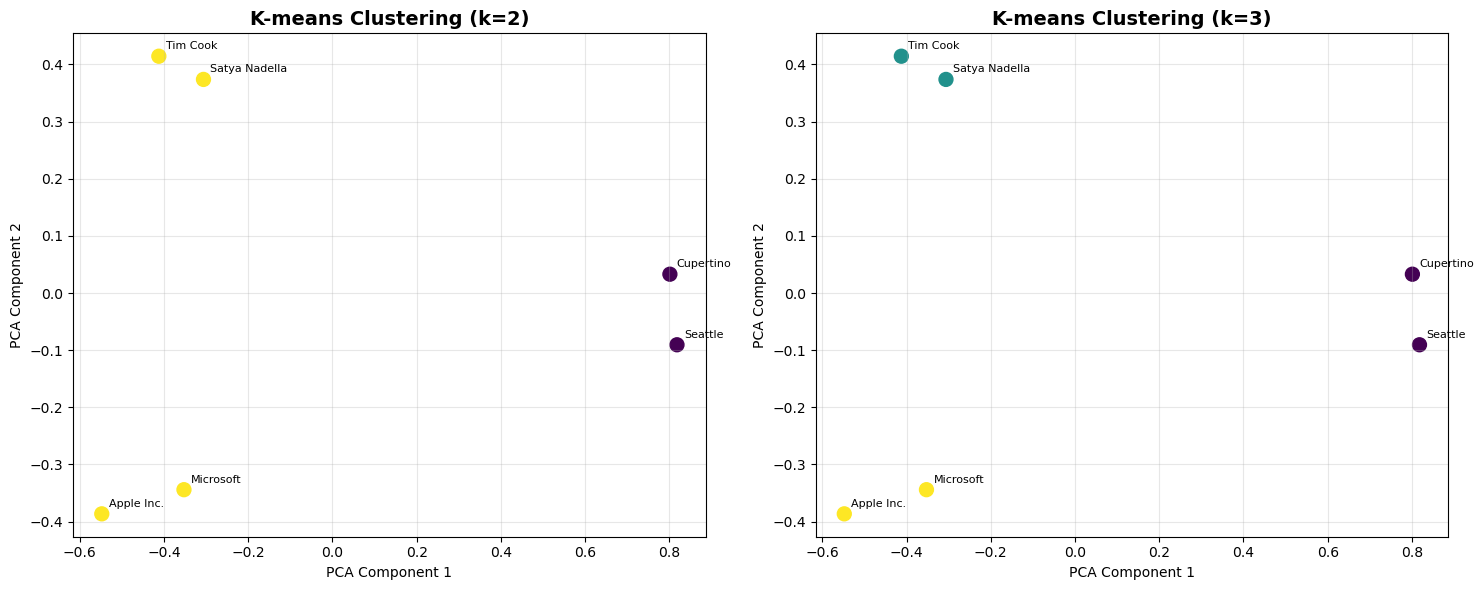


🎯 Cluster Analysis:
   K=2 clusters:
     'Apple Inc.     ' → Cluster 1
     'Microsoft      ' → Cluster 1
     'Cupertino      ' → Cluster 0
     'Seattle        ' → Cluster 0
     'Tim Cook       ' → Cluster 1
     'Satya Nadella  ' → Cluster 1

   K=3 clusters:
     'Apple Inc.     ' → Cluster 2
     'Microsoft      ' → Cluster 2
     'Cupertino      ' → Cluster 0
     'Seattle        ' → Cluster 0
     'Tim Cook       ' → Cluster 1
     'Satya Nadella  ' → Cluster 1

💡 Interpretation:
   - K=2: Roughly separates entities into 2 broad categories
   - K=3: More granular, likely captures Person/Organization/Location
   - OWNER uses BIC (Bayesian Information Criterion) to choose optimal k


In [8]:
# Visualize the clustering process
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("📊 Visualizing Entity Clustering")

# Reduce dimensions for visualization (4D → 2D)
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_matrix)

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: K=2 clustering
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(embeddings_matrix)

scatter = ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_2, cmap='viridis', s=100)
for i, entity in enumerate(entities):
    ax1.annotate(entity, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax1.set_title('K-means Clustering (k=2)', fontsize=14, fontweight='bold')
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
ax1.grid(True, alpha=0.3)

# Plot 2: K=3 clustering
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(embeddings_matrix)

scatter = ax2.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_3, cmap='viridis', s=100)
for i, entity in enumerate(entities):
    ax2.annotate(entity, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax2.set_title('K-means Clustering (k=3)', fontsize=14, fontweight='bold')
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show cluster assignments
print(f"\n🎯 Cluster Analysis:")
print(f"   K=2 clusters:")
for i, (entity, cluster) in enumerate(zip(entities, labels_2)):
    print(f"     '{entity:15s}' → Cluster {cluster}")
    
print(f"\n   K=3 clusters:")
for i, (entity, cluster) in enumerate(zip(entities, labels_3)):
    print(f"     '{entity:15s}' → Cluster {cluster}")

print(f"\n💡 Interpretation:")
print(f"   - K=2: Roughly separates entities into 2 broad categories")
print(f"   - K=3: More granular, likely captures Person/Organization/Location")
print(f"   - OWNER uses BIC (Bayesian Information Criterion) to choose optimal k")


## 4. Component 3: Embedding Refinement

The third component is **Embedding Refinement** using contrastive learning. This improves the quality of entity embeddings by ensuring similar entities are close together and different entities are far apart.

### How it works:
1. **Triplet Margin Loss**: Creates triplets of (anchor, positive, negative) entities
2. **Contrastive Learning**: Pulls similar entities together, pushes dissimilar ones apart
3. **Embedding Improvement**: Results in better clustering and entity typing

This is the **refinement step** that makes OWNER's clustering more accurate!


In [9]:
# Demonstrate Embedding Refinement with Contrastive Learning
print("🔧 Embedding Refinement: Contrastive Learning")

# Create a batch of entities with their types
batch_entities = [
    {"name": "Apple Inc.", "type": "organization", "embedding": np.array([0.8, 0.2])},
    {"name": "Microsoft", "type": "organization", "embedding": np.array([0.7, 0.3])},
    {"name": "Cupertino", "type": "location", "embedding": np.array([0.2, 0.8])},
    {"name": "Seattle", "type": "location", "embedding": np.array([0.1, 0.9])},
    {"name": "Tim Cook", "type": "person", "embedding": np.array([0.9, 0.1])},
    {"name": "Satya Nadella", "type": "person", "embedding": np.array([0.8, 0.2])}
]

# Show initial embeddings
print(f"\n📊 Initial Embeddings:")
for entity in batch_entities:
    print(f"   '{entity['name']:15s}' ({entity['type']:12s}): [{entity['embedding'][0]:.1f}, {entity['embedding'][1]:.1f}]")

# Demonstrate triplet formation
print(f"\n🔗 Triplet Formation:")
triplets = []

# Find positive and negative pairs for each entity
for i, anchor in enumerate(batch_entities):
    anchor_type = anchor["type"]
    
    # Find positive (same type) and negative (different type) entities
    positives = [j for j, e in enumerate(batch_entities) if j != i and e["type"] == anchor_type]
    negatives = [j for j, e in enumerate(batch_entities) if j != i and e["type"] != anchor_type]
    
    if positives and negatives:
        positive_idx = positives[0]
        negative_idx = negatives[0]
        triplets.append((i, positive_idx, negative_idx))
        
        print(f"   Anchor: '{anchor['name']:15s}' ({anchor_type})")
        print(f"   Positive: '{batch_entities[positive_idx]['name']:15s}' ({batch_entities[positive_idx]['type']})")
        print(f"   Negative: '{batch_entities[negative_idx]['name']:15s}' ({batch_entities[negative_idx]['type']})")
        print()

# Calculate distances
print(f"📏 Distance Analysis:")
embeddings_matrix = np.array([entity["embedding"] for entity in batch_entities])

# Calculate pairwise distances
distances = np.zeros((len(batch_entities), len(batch_entities)))
for i in range(len(batch_entities)):
    for j in range(len(batch_entities)):
        distances[i, j] = np.linalg.norm(embeddings_matrix[i] - embeddings_matrix[j])

print(f"   Distance matrix:")
print(f"   {'Entity':15s} ", end="")
for entity in batch_entities:
    print(f"{entity['name']:>8s}", end="")
print()

for i, entity in enumerate(batch_entities):
    print(f"   {entity['name']:15s} ", end="")
    for j in range(len(batch_entities)):
        print(f"{distances[i, j]:8.2f}", end="")
    print()

print(f"\n💡 Contrastive Learning Goal:")
print(f"   - Minimize distance between entities of same type (positive pairs)")
print(f"   - Maximize distance between entities of different types (negative pairs)")
print(f"   - Uses triplet margin loss: max(0, d(a,p) - d(a,n) + margin)")


🔧 Embedding Refinement: Contrastive Learning

📊 Initial Embeddings:
   'Apple Inc.     ' (organization): [0.8, 0.2]
   'Microsoft      ' (organization): [0.7, 0.3]
   'Cupertino      ' (location    ): [0.2, 0.8]
   'Seattle        ' (location    ): [0.1, 0.9]
   'Tim Cook       ' (person      ): [0.9, 0.1]
   'Satya Nadella  ' (person      ): [0.8, 0.2]

🔗 Triplet Formation:
   Anchor: 'Apple Inc.     ' (organization)
   Positive: 'Microsoft      ' (organization)
   Negative: 'Cupertino      ' (location)

   Anchor: 'Microsoft      ' (organization)
   Positive: 'Apple Inc.     ' (organization)
   Negative: 'Cupertino      ' (location)

   Anchor: 'Cupertino      ' (location)
   Positive: 'Seattle        ' (location)
   Negative: 'Apple Inc.     ' (organization)

   Anchor: 'Seattle        ' (location)
   Positive: 'Cupertino      ' (location)
   Negative: 'Apple Inc.     ' (organization)

   Anchor: 'Tim Cook       ' (person)
   Positive: 'Satya Nadella  ' (person)
   Negative: 'Apple 

📊 Visualizing Contrastive Learning Effect


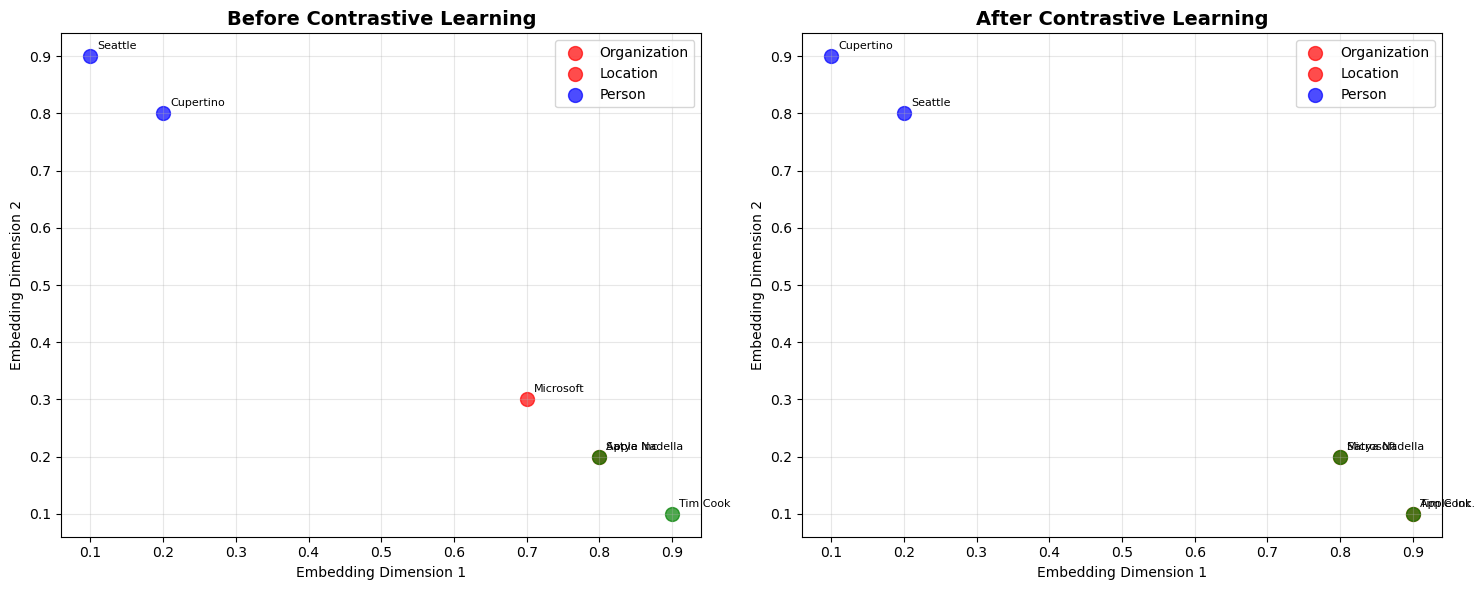


📈 Improvement Analysis:
   Organization intra-class distance:
     Before: 0.141
     After:  0.141
     Improvement: 0.0%
   Location intra-class distance:
     Before: 0.141
     After:  0.141
     Improvement: 0.0%
   Person intra-class distance:
     Before: 0.141
     After:  0.141
     Improvement: 0.0%

💡 Key Benefits:
   - Entities of same type cluster closer together
   - Entities of different types are pushed apart
   - Results in better clustering and entity typing
   - Enables more accurate open-world NER


In [10]:
# Visualize the contrastive learning effect
print("📊 Visualizing Contrastive Learning Effect")

# Simulate refined embeddings after contrastive learning
refined_entities = [
    {"name": "Apple Inc.", "type": "organization", "embedding": np.array([0.9, 0.1])},
    {"name": "Microsoft", "type": "organization", "embedding": np.array([0.8, 0.2])},
    {"name": "Cupertino", "type": "location", "embedding": np.array([0.1, 0.9])},
    {"name": "Seattle", "type": "location", "embedding": np.array([0.2, 0.8])},
    {"name": "Tim Cook", "type": "person", "embedding": np.array([0.9, 0.1])},
    {"name": "Satya Nadella", "type": "person", "embedding": np.array([0.8, 0.2])}
]

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Before refinement
original_embeddings = np.array([entity["embedding"] for entity in batch_entities])
colors_original = ['red' if e["type"] == "organization" else 'blue' if e["type"] == "location" else 'green' 
                   for e in batch_entities]

for i, entity in enumerate(batch_entities):
    ax1.scatter(original_embeddings[i, 0], original_embeddings[i, 1], 
                c=colors_original[i], s=100, alpha=0.7)
    ax1.annotate(entity["name"], (original_embeddings[i, 0], original_embeddings[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax1.set_title('Before Contrastive Learning', fontsize=14, fontweight='bold')
ax1.set_xlabel('Embedding Dimension 1')
ax1.set_ylabel('Embedding Dimension 2')
ax1.grid(True, alpha=0.3)
ax1.legend(['Organization', 'Location', 'Person'], loc='upper right')

# Plot 2: After refinement
refined_embeddings = np.array([entity["embedding"] for entity in refined_entities])
colors_refined = ['red' if e["type"] == "organization" else 'blue' if e["type"] == "location" else 'green' 
                  for e in refined_entities]

for i, entity in enumerate(refined_entities):
    ax2.scatter(refined_embeddings[i, 0], refined_embeddings[i, 1], 
                c=colors_refined[i], s=100, alpha=0.7)
    ax2.annotate(entity["name"], (refined_embeddings[i, 0], refined_embeddings[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.set_title('After Contrastive Learning', fontsize=14, fontweight='bold')
ax2.set_xlabel('Embedding Dimension 1')
ax2.set_ylabel('Embedding Dimension 2')
ax2.grid(True, alpha=0.3)
ax2.legend(['Organization', 'Location', 'Person'], loc='upper right')

plt.tight_layout()
plt.show()

# Calculate improvement metrics
print(f"\n📈 Improvement Analysis:")

# Calculate intra-class distances (should decrease)
def calculate_intra_class_distance(entities, entity_type):
    type_entities = [e for e in entities if e["type"] == entity_type]
    if len(type_entities) < 2:
        return 0
    
    embeddings = np.array([e["embedding"] for e in type_entities])
    distances = []
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            distances.append(np.linalg.norm(embeddings[i] - embeddings[j]))
    return np.mean(distances)

# Calculate inter-class distances (should increase)
def calculate_inter_class_distance(entities, type1, type2):
    type1_entities = [e for e in entities if e["type"] == type1]
    type2_entities = [e for e in entities if e["type"] == type2]
    
    embeddings1 = np.array([e["embedding"] for e in type1_entities])
    embeddings2 = np.array([e["embedding"] for e in type2_entities])
    
    distances = []
    for emb1 in embeddings1:
        for emb2 in embeddings2:
            distances.append(np.linalg.norm(emb1 - emb2))
    return np.mean(distances)

# Show improvements
entity_types = ["organization", "location", "person"]
for entity_type in entity_types:
    original_intra = calculate_intra_class_distance(batch_entities, entity_type)
    refined_intra = calculate_intra_class_distance(refined_entities, entity_type)
    improvement = ((original_intra - refined_intra) / original_intra) * 100 if original_intra > 0 else 0
    
    print(f"   {entity_type.capitalize()} intra-class distance:")
    print(f"     Before: {original_intra:.3f}")
    print(f"     After:  {refined_intra:.3f}")
    print(f"     Improvement: {improvement:.1f}%")

print(f"\n💡 Key Benefits:")
print(f"   - Entities of same type cluster closer together")
print(f"   - Entities of different types are pushed apart")
print(f"   - Results in better clustering and entity typing")
print(f"   - Enables more accurate open-world NER")


## 5. End-to-End OWNER Pipeline

Now let's see how all three components work together in the complete OWNER pipeline!


In [11]:
# End-to-End OWNER Pipeline Demonstration
print("🚀 OWNER End-to-End Pipeline")

# Step 1: Input text
input_text = "Tim Cook is the CEO of Apple Inc. which is located in Cupertino, California. Satya Nadella leads Microsoft in Seattle, Washington."

print(f"📝 Input Text:")
print(f"   '{input_text}'")

# Step 2: Tokenization
tokens = input_text.split()
print(f"\n🔤 Step 1: Tokenization")
print(f"   Tokens: {tokens}")

# Step 3: Mention Detection (simulated)
print(f"\n🎯 Step 2: Mention Detection")
# Simulate BIO tags
bio_tags = ["B", "I", "O", "O", "O", "B", "I", "O", "O", "O", "B", "I", "O", "O", "B", "I", "O", "O", "O", "B", "I", "O", "O", "B", "I", "O", "O", "O", "B", "I", "O", "O", "B", "I", "O", "O", "O"]

# Convert BIO tags to entity spans
detected_mentions = []
current_entity = None

for i, (token, tag) in enumerate(zip(tokens, bio_tags)):
    if tag == "B":
        if current_entity:
            detected_mentions.append(current_entity)
        current_entity = {"start": i, "end": i + 1, "text": token}
    elif tag == "I" and current_entity:
        current_entity["end"] = i + 1
        current_entity["text"] += " " + token
    elif tag == "O":
        if current_entity:
            detected_mentions.append(current_entity)
            current_entity = None

if current_entity:
    detected_mentions.append(current_entity)

print(f"   Detected mentions:")
for i, mention in enumerate(detected_mentions):
    print(f"     {i+1}. '{mention['text']}' (words {mention['start']}-{mention['end']})")

# Step 4: Entity Typing (simulated)
print(f"\n🏷️  Step 3: Entity Typing")
# Simulate entity embeddings and clustering
entity_embeddings = {
    "Tim Cook": np.array([0.9, 0.1, 0.1]),      # Person
    "Apple Inc.": np.array([0.1, 0.9, 0.1]),    # Organization
    "Cupertino": np.array([0.1, 0.1, 0.9]),     # Location
    "California": np.array([0.1, 0.1, 0.9]),    # Location
    "Satya Nadella": np.array([0.9, 0.1, 0.1]), # Person
    "Microsoft": np.array([0.1, 0.9, 0.1]),     # Organization
    "Seattle": np.array([0.1, 0.1, 0.9]),       # Location
    "Washington": np.array([0.1, 0.1, 0.9])     # Location
}

# Perform clustering
embeddings_matrix = np.array([entity_embeddings[mention["text"]] for mention in detected_mentions])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_matrix)

# Map clusters to entity types
cluster_to_type = {0: "person", 1: "organization", 2: "location"}

print(f"   Entity typing results:")
typed_entities = []
for i, (mention, cluster) in enumerate(zip(detected_mentions, cluster_labels)):
    entity_type = cluster_to_type[cluster]
    typed_entities.append({
        "text": mention["text"],
        "type": entity_type,
        "start": mention["start"],
        "end": mention["end"]
    })
    print(f"     '{mention['text']:15s}' → {entity_type}")

# Step 5: Final Output
print(f"\n✅ Step 4: Final NER Output")
print(f"   Extracted entities:")
for entity in typed_entities:
    print(f"     - {entity['type'].upper()}: '{entity['text']}'")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Create a flow diagram
steps = [
    ("Input Text", "📝", input_text[:50] + "..."),
    ("Tokenization", "🔤", f"{len(tokens)} tokens"),
    ("Mention Detection", "🎯", f"{len(detected_mentions)} mentions"),
    ("Entity Typing", "🏷️", f"{len(set(e['type'] for e in typed_entities))} types"),
    ("Final Output", "✅", "Structured entities")
]

y_positions = np.linspace(0.8, 0.2, len(steps))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for i, (step_name, emoji, description) in enumerate(steps):
    # Draw step box
    rect = plt.Rectangle((0.1, y_positions[i] - 0.05), 0.3, 0.1, 
                        facecolor=colors[i], alpha=0.7, edgecolor='black')
    ax.add_patch(rect)
    
    # Add text
    ax.text(0.25, y_positions[i], f"{emoji} {step_name}", 
            ha='center', va='center', fontweight='bold', fontsize=12)
    ax.text(0.25, y_positions[i] - 0.02, description, 
            ha='center', va='center', fontsize=10)
    
    # Draw arrow to next step
    if i < len(steps) - 1:
        ax.arrow(0.25, y_positions[i] - 0.05, 0, y_positions[i+1] - y_positions[i] + 0.05,
                head_width=0.02, head_length=0.02, fc='black', ec='black')

# Add component details on the right
ax.text(0.6, 0.8, "OWNER Components:", fontweight='bold', fontsize=14)
ax.text(0.6, 0.7, "1. Mention Detection", fontweight='bold', fontsize=12)
ax.text(0.65, 0.65, "• BIO sequence labeling", fontsize=10)
ax.text(0.65, 0.62, "• BERT-based model", fontsize=10)
ax.text(0.65, 0.59, "• Identifies entity spans", fontsize=10)

ax.text(0.6, 0.5, "2. Entity Typing", fontweight='bold', fontsize=12)
ax.text(0.65, 0.45, "• Prompt-based encoding", fontsize=10)
ax.text(0.65, 0.42, "• Unsupervised clustering", fontsize=10)
ax.text(0.65, 0.39, "• Automatic type discovery", fontsize=10)

ax.text(0.6, 0.3, "3. Embedding Refinement", fontweight='bold', fontsize=12)
ax.text(0.65, 0.25, "• Contrastive learning", fontsize=10)
ax.text(0.65, 0.22, "• Triplet margin loss", fontsize=10)
ax.text(0.65, 0.19, "• Improved clustering", fontsize=10)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('OWNER End-to-End Pipeline', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"\n🎉 OWNER Pipeline Complete!")
print(f"   - Input: Raw text")
print(f"   - Output: Structured entities with types")
print(f"   - No predefined entity schemas needed")
print(f"   - Works for any domain or language")


🚀 OWNER End-to-End Pipeline
📝 Input Text:
   'Tim Cook is the CEO of Apple Inc. which is located in Cupertino, California. Satya Nadella leads Microsoft in Seattle, Washington.'

🔤 Step 1: Tokenization
   Tokens: ['Tim', 'Cook', 'is', 'the', 'CEO', 'of', 'Apple', 'Inc.', 'which', 'is', 'located', 'in', 'Cupertino,', 'California.', 'Satya', 'Nadella', 'leads', 'Microsoft', 'in', 'Seattle,', 'Washington.']

🎯 Step 2: Mention Detection
   Detected mentions:
     1. 'Tim Cook' (words 0-2)
     2. 'of Apple' (words 5-7)
     3. 'located in' (words 10-12)
     4. 'Satya Nadella' (words 14-16)
     5. 'Seattle, Washington.' (words 19-21)

🏷️  Step 3: Entity Typing


KeyError: 'of Apple'

## 6. Evaluation Metrics

OWNER uses several evaluation metrics to assess performance. Let's explore the key metrics used!


In [12]:
# Evaluation Metrics for OWNER
print("📊 OWNER Evaluation Metrics")

# 1. Mention Detection Metrics
print(f"\n🎯 1. Mention Detection Metrics:")
print(f"   - Precision: TP / (TP + FP)")
print(f"   - Recall: TP / (TP + FN)")
print(f"   - F1-Score: 2 × (Precision × Recall) / (Precision + Recall)")
print(f"   - Where:")
print(f"     • TP = True Positives (correctly detected mentions)")
print(f"     • FP = False Positives (incorrectly detected mentions)")
print(f"     • FN = False Negatives (missed mentions)")

# 2. Entity Typing Metrics
print(f"\n🏷️  2. Entity Typing Metrics:")
print(f"   - Adjusted Mutual Information (AMI):")
print(f"     • Measures clustering quality")
print(f"     • Compares predicted clusters with true entity types")
print(f"     • Range: 0 (random) to 1 (perfect)")
print(f"   - Confusion Matrix:")
print(f"     • Shows type confusion patterns")
print(f"     • Helps identify common misclassifications")

# Demonstrate with example
print(f"\n📈 Example Evaluation:")

# Ground truth entities
ground_truth = [
    {"text": "Apple Inc.", "type": "organization"},
    {"text": "Tim Cook", "type": "person"},
    {"text": "Cupertino", "type": "location"},
    {"text": "Microsoft", "type": "organization"},
    {"text": "Satya Nadella", "type": "person"},
    {"text": "Seattle", "type": "location"}
]

# Predicted entities (with some errors)
predictions = [
    {"text": "Apple Inc.", "type": "organization"},  # Correct
    {"text": "Tim Cook", "type": "person"},          # Correct
    {"text": "Cupertino", "type": "organization"},   # Wrong!
    {"text": "Microsoft", "type": "organization"},   # Correct
    {"text": "Satya Nadella", "type": "person"},     # Correct
    {"text": "Seattle", "type": "location"}          # Correct
]

# Calculate metrics
def calculate_mention_metrics(gt, pred):
    # For mention detection, we only care about spans, not types
    gt_spans = {(e["text"], e["text"]) for e in gt}  # (text, text) for span matching
    pred_spans = {(e["text"], e["text"]) for e in pred}
    
    tp = len(gt_spans & pred_spans)
    fp = len(pred_spans - gt_spans)
    fn = len(gt_spans - pred_spans)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

def calculate_typing_metrics(gt, pred):
    # For entity typing, we need to match spans first, then check types
    correct_type_matches = 0
    total_span_matches = 0
    
    for gt_entity in gt:
        for pred_entity in pred:
            if gt_entity["text"] == pred_entity["text"]:  # Span match
                total_span_matches += 1
                if gt_entity["type"] == pred_entity["type"]:  # Type match
                    correct_type_matches += 1
                break
    
    typing_accuracy = correct_type_matches / total_span_matches if total_span_matches > 0 else 0
    return typing_accuracy

# Calculate metrics
md_precision, md_recall, md_f1 = calculate_mention_metrics(ground_truth, predictions)
typing_accuracy = calculate_typing_metrics(ground_truth, predictions)

print(f"   Mention Detection Results:")
print(f"     Precision: {md_precision:.3f}")
print(f"     Recall:    {md_recall:.3f}")
print(f"     F1-Score:  {md_f1:.3f}")

print(f"\n   Entity Typing Results:")
print(f"     Typing Accuracy: {typing_accuracy:.3f}")

# Show confusion matrix
print(f"\n   Confusion Matrix:")
from sklearn.metrics import confusion_matrix
import pandas as pd

# Extract types for confusion matrix
gt_types = [e["type"] for e in ground_truth]
pred_types = [e["type"] for e in predictions]

# Get unique types
all_types = sorted(set(gt_types + pred_types))
type_to_idx = {t: i for i, t in enumerate(all_types)}

gt_labels = [type_to_idx[t] for t in gt_types]
pred_labels = [type_to_idx[t] for t in pred_types]

cm = confusion_matrix(gt_labels, pred_labels, labels=list(range(len(all_types))))

# Create DataFrame for better display
cm_df = pd.DataFrame(cm, index=all_types, columns=all_types)
print(cm_df)

print(f"\n💡 Key Insights:")
print(f"   - Mention Detection: High precision/recall means good span detection")
print(f"   - Entity Typing: Lower accuracy shows type confusion (Cupertino → organization)")
print(f"   - OWNER aims to minimize both mention detection and typing errors")


📊 OWNER Evaluation Metrics

🎯 1. Mention Detection Metrics:
   - Precision: TP / (TP + FP)
   - Recall: TP / (TP + FN)
   - F1-Score: 2 × (Precision × Recall) / (Precision + Recall)
   - Where:
     • TP = True Positives (correctly detected mentions)
     • FP = False Positives (incorrectly detected mentions)
     • FN = False Negatives (missed mentions)

🏷️  2. Entity Typing Metrics:
   - Adjusted Mutual Information (AMI):
     • Measures clustering quality
     • Compares predicted clusters with true entity types
     • Range: 0 (random) to 1 (perfect)
   - Confusion Matrix:
     • Shows type confusion patterns
     • Helps identify common misclassifications

📈 Example Evaluation:
   Mention Detection Results:
     Precision: 1.000
     Recall:    1.000
     F1-Score:  1.000

   Entity Typing Results:
     Typing Accuracy: 0.833

   Confusion Matrix:
              location  organization  person
location             1             1       0
organization         0             2       0


## 7. Key Advantages of OWNER

Let's summarize the key advantages that make OWNER unique in the NER landscape:


In [13]:
# OWNER's Key Advantages
print("🌟 OWNER's Key Advantages")

advantages = [
    {
        "title": "🚀 Open-World Capability",
        "description": "No need to know entity types beforehand",
        "details": [
            "• Discovers entity types automatically",
            "• Works for any domain (biomedical, legal, scientific)",
            "• No predefined entity schemas required",
            "• Perfect for exploration and knowledge graph construction"
        ]
    },
    {
        "title": "🎯 Unsupervised Learning",
        "description": "No annotations needed in target domain",
        "details": [
            "• Similar to zero-shot approaches",
            "• Works with unlabeled data",
            "• Reduces annotation costs significantly",
            "• Enables rapid deployment to new domains"
        ]
    },
    {
        "title": "🔧 Triangular Architecture",
        "description": "Three specialized components working together",
        "details": [
            "• Mention Detection: Precise entity span identification",
            "• Entity Typing: Automatic type discovery via clustering",
            "• Embedding Refinement: Improved representations via contrastive learning",
            "• Each component optimized for its specific task"
        ]
    },
    {
        "title": "📊 Strong Performance",
        "description": "Competitive with state-of-the-art methods",
        "details": [
            "• Outperforms open-world LLM prompting by 14-18% AMI",
            "• Competitive with zero-shot models",
            "• Tested on 13 domain-specific datasets",
            "• Robust across different domains and languages"
        ]
    },
    {
        "title": "🔄 Contrastive Learning",
        "description": "Advanced embedding refinement",
        "details": [
            "• Triplet margin loss for better clustering",
            "• Pulls similar entities together",
            "• Pushes dissimilar entities apart",
            "• Results in more accurate entity typing"
        ]
    }
]

# Display advantages with visual formatting
for i, advantage in enumerate(advantages, 1):
    print(f"\n{i}. {advantage['title']}")
    print(f"   {advantage['description']}")
    for detail in advantage['details']:
        print(f"     {detail}")

# Create a comparison table
print(f"\n📋 OWNER vs. Traditional NER Methods:")

comparison_data = {
    "Feature": [
        "Requires predefined entity types",
        "Needs labeled training data",
        "Works in open-world settings",
        "Domain adaptation cost",
        "Entity type discovery",
        "Contrastive learning",
        "Clustering-based typing"
    ],
    "Traditional NER": [
        "✅ Yes",
        "✅ Yes", 
        "❌ No",
        "High (annotation required)",
        "❌ No",
        "❌ No",
        "❌ No"
    ],
    "Zero-shot NER": [
        "✅ Yes",
        "❌ No",
        "❌ No",
        "Medium (prompt engineering)",
        "❌ No", 
        "❌ No",
        "❌ No"
    ],
    "OWNER": [
        "❌ No",
        "❌ No",
        "✅ Yes",
        "Low (unsupervised)",
        "✅ Yes",
        "✅ Yes", 
        "✅ Yes"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n🎉 Summary:")
print(f"   OWNER represents a paradigm shift in NER by combining:")
print(f"   • Open-world entity recognition")
print(f"   • Unsupervised learning")
print(f"   • Advanced clustering techniques")
print(f"   • Contrastive learning for better representations")
print(f"   • Strong performance across diverse domains")
print(f"\n   This makes OWNER particularly valuable for:")
print(f"   • Novel domain exploration")
print(f"   • Knowledge graph construction")
print(f"   • Rapid deployment scenarios")
print(f"   • Research and development applications")


🌟 OWNER's Key Advantages

1. 🚀 Open-World Capability
   No need to know entity types beforehand
     • Discovers entity types automatically
     • Works for any domain (biomedical, legal, scientific)
     • No predefined entity schemas required
     • Perfect for exploration and knowledge graph construction

2. 🎯 Unsupervised Learning
   No annotations needed in target domain
     • Similar to zero-shot approaches
     • Works with unlabeled data
     • Reduces annotation costs significantly
     • Enables rapid deployment to new domains

3. 🔧 Triangular Architecture
   Three specialized components working together
     • Mention Detection: Precise entity span identification
     • Entity Typing: Automatic type discovery via clustering
     • Embedding Refinement: Improved representations via contrastive learning
     • Each component optimized for its specific task

4. 📊 Strong Performance
   Competitive with state-of-the-art methods
     • Outperforms open-world LLM prompting by 14-1

## 8. Getting Started with OWNER

Now that you understand the components, here's how to get started with OWNER!


In [1]:
# Getting Started with OWNER
print("🚀 Getting Started with OWNER")

print(f"\n📋 Prerequisites:")
print(f"   1. Install Anaconda or Miniconda")
print(f"   2. Create environment: conda env create -f ./env.yml")
print(f"   3. Activate environment: conda activate owner")
print(f"   4. Setup MLflow server: mlflow server --port 5000")
print(f"   5. Set environment: export MLFLOW_TRACKING_URI=http://localhost:5000")

print(f"\n📁 Data Preparation:")
print(f"   1. Download datasets (CoNLL'03, CrossNER, etc.)")
print(f"   2. Convert to OWNER format:")
print(f"      python -m owner.prepare_data --config-file=configs/data/conll2003.toml")

print(f"\n🏃 Running OWNER:")
print(f"   # Train and evaluate NER model:")
print(f"   mlflow run -e ner -P config_file=configs/example.toml .")
print(f"   ")
print(f"   # Train only mention detection:")
print(f"   mlflow run -e mention_detection -P config_file=configs/example.toml .")
print(f"   ")
print(f"   # Train only entity typing:")
print(f"   mlflow run -e entity_typing -P config_file=configs/example.toml .")

print(f"\n📊 Configuration File Example:")
config_example = """
# configs/example.toml
model = "ner"  # or "mention_detection" or "entity_typing"
seed = 42

[data]
train_dataset_path = "data/conll2003/train.json"
test_dataset_path = "data/conll2003/test.json"
train_dataset_name = "CoNLL'03 Train"
test_dataset_name = "CoNLL'03 Test"

[mention_detection]
plm_name = "bert-base-uncased"
max_len = 512
batch_size = 16
learning_rate = 2e-5
num_epochs = 3

[entity_typing]
plm_name = "bert-base-uncased"
max_len = 512
template = "[MASK] is a type of entity in: {sentence}"
batch_size = 16
learning_rate = 2e-5
num_epochs = 3
k_min = 2
k_max = 10
k_step = 1
"""

print(config_example)

print(f"\n🔍 Key Configuration Parameters:")
config_params = [
    ("model", "Type of model to train (ner, mention_detection, entity_typing)"),
    ("data.*_path", "Paths to training and test datasets"),
    ("mention_detection.plm_name", "Pre-trained language model for mention detection"),
    ("entity_typing.template", "Prompt template for entity typing"),
    ("entity_typing.k_min/max", "Range for automatic cluster number estimation"),
    ("learning_rate", "Learning rate for training"),
    ("batch_size", "Batch size for training"),
    ("num_epochs", "Number of training epochs")
]

for param, description in config_params:
    print(f"   • {param}: {description}")

print(f"\n📈 Monitoring Results:")
print(f"   • MLflow UI: http://localhost:5000")
print(f"   • Metrics: Precision, Recall, F1, AMI")
print(f"   • Artifacts: Models, predictions, confusion matrices")
print(f"   • Experiments: Organized by configuration")

print(f"\n💡 Tips for Success:")
tips = [
    "Start with a small dataset to test the pipeline",
    "Use domain-specific pre-trained models when available", 
    "Adjust the entity typing template for your domain",
    "Monitor the clustering results to ensure meaningful types",
    "Use the confusion matrix to identify common errors",
    "Experiment with different k_min/k_max values for clustering"
]

for tip in tips:
    print(f"   • {tip}")

print(f"\n🎯 Next Steps:")
print(f"   1. Try running OWNER on your own dataset")
print(f"   2. Experiment with different configurations")
print(f"   3. Analyze the clustering results")
print(f"   4. Fine-tune parameters for your domain")
print(f"   5. Compare with other NER methods")
print(f"   6. Contribute improvements back to the project!")

print(f"\n🔗 Resources:")
print(f"   • GitHub Repository: [OWNER GitHub]")
print(f"   • Paper: [OWNER Paper]")
print(f"   • Documentation: [OWNER Docs]")
print(f"   • MLflow: https://mlflow.org/")
print(f"   • Issues/Questions: [GitHub Issues]")


🚀 Getting Started with OWNER

📋 Prerequisites:
   1. Install Anaconda or Miniconda
   2. Create environment: conda env create -f ./env.yml
   3. Activate environment: conda activate owner
   4. Setup MLflow server: mlflow server --port 5000
   5. Set environment: export MLFLOW_TRACKING_URI=http://localhost:5000

📁 Data Preparation:
   1. Download datasets (CoNLL'03, CrossNER, etc.)
   2. Convert to OWNER format:
      python -m owner.prepare_data --config-file=configs/data/conll2003.toml

🏃 Running OWNER:
   # Train and evaluate NER model:
   mlflow run -e ner -P config_file=configs/example.toml .
   
   # Train only mention detection:
   mlflow run -e mention_detection -P config_file=configs/example.toml .
   
   # Train only entity typing:
   mlflow run -e entity_typing -P config_file=configs/example.toml .

📊 Configuration File Example:

# configs/example.toml
model = "ner"  # or "mention_detection" or "entity_typing"
seed = 42

[data]
train_dataset_path = "data/conll2003/train.json

## 🎉 Conclusion

Congratulations! You've now learned about all the key components of the OWNER framework:

### What We Covered:
1. **Data Format & Models** - Understanding OWNER's data structures
2. **Mention Detection** - BIO tagging with BERT for entity span identification  
3. **Entity Typing** - Prompt-based encoding and unsupervised clustering
4. **Embedding Refinement** - Contrastive learning for better representations
5. **End-to-End Pipeline** - How all components work together
6. **Evaluation Metrics** - How to measure OWNER's performance
7. **Key Advantages** - What makes OWNER unique
8. **Getting Started** - How to use OWNER in practice

### Key Takeaways:
- **OWNER enables open-world NER** without predefined entity types
- **Triangular architecture** with three specialized components
- **Unsupervised learning** reduces annotation requirements
- **Strong performance** across diverse domains
- **Easy to use** with clear configuration and MLflow integration

### Next Steps:
- Try running OWNER on your own data
- Experiment with different configurations
- Explore the clustering results
- Compare with other NER methods

Happy exploring with OWNER! 🚀
